[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke05-agentisk-ai/02_agentisk_ai_i_helse.ipynb)


# Agentisk AI i helse

## Læringsmål

- Forstå hvordan en språkmodell kan bruke verktøy for å løse oppgaver i flere steg.
- Kjenne hovedideen bak RAG, enkel minnebruk og tilstand.
- Diskutere helserelevante anvendelser av agentisk AI.
- Reflektere over grenser, personvern, logging og menneskelig kontroll.
- Kunne forklare hvorfor agentisk AI må vurderes annerledes enn en vanlig chatbot.

> **Merk:** Dette er pedagogisk materiale. Eksemplene er laget for læring og refleksjon, ikke for klinisk beslutningsstøtte.

Denne notebooken bygger videre på forrige notebook og viser hvordan agentiske systemer kan brukes som støtte i helse og omsorg. Vi holder eksemplene enkle og trygge, med syntetiske data og lokale tekstbiter fremfor ekte pasientinformasjon.


## Viktige idéer

Et agentisk system kan bestå av flere deler:

- **mål**: hva systemet forsøker å oppnå
- **modell**: språkmodellen som foreslår svar eller neste steg
- **verktøy**: oppslag, søk, dokumentlesing eller andre funksjoner
- **hukommelse/tilstand**: hva systemet husker fra tidligere steg
- **kontrollmekanismer**: regler for hva som er lov, og når mennesket må godkjenne

**RAG** (retrieval-augmented generation) betyr at modellen får hjelp av oppslag i relevante dokumenter eller kunnskapskilder. I helse kan dette være nyttig fordi svar da kan forankres i prosedyrer, retningslinjer eller lokal dokumentasjon i stedet for bare i modellens generelle forhåndskunnskap.

## Fra modell til system

I uke 4 arbeidet du hovedsakelig med modeller: hva de kan svare, hvordan de promptes, og hvordan de brukes via API. I uke 5 ser vi på noe mer sammensatt: et **system** som bruker modellen som en komponent i en arbeidsflyt.

Et slikt system kan for eksempel:

- lese et spørsmål
- velge om det trenger oppslag i en kunnskapskilde
- hente relevant tekst
- huske hva som nettopp ble spurt om
- lage et forslag som senere må kvalitetssikres av et menneske

Det er dette som gjør agentisk AI interessant, men også mer krevende å vurdere enn en vanlig chatbot.


## Fra enkeltagent til tverrfaglig team

I helse og omsorg er mange oppgaver ikke bare tekniske, men også tverrfaglige. En pasients situasjon kan måtte vurderes fra flere perspektiver samtidig: funksjon, kommunikasjon, medisiner, oppfølging hjemme og koordinering mellom tjenester.

**Agentbasert KI** kan derfor forstås som en tilnærming der ett system ikke bare gir ett svar, men organiserer arbeid i flere steg eller roller. I noen tilfeller kan disse rollene fungere som et lite digitalt team, der ulike agenter bidrar med ulike perspektiver før et menneske tar stilling til resultatet.

Et slikt oppsett er ikke automatisk tryggere fordi det er mer avansert. Tvert imot: jo flere deler som inngår, desto viktigere blir ansvar, logging, avgrensning og menneskelig kontroll.


In [5]:
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt

knowledge_base = {
    "hypertensjon": "Ved vedvarende høyt blodtrykk bør pasienten følges opp med livsstilsråd, nye målinger og vurdering av medikamentell behandling.",
    "diabetes": "Ved mistanke om diabetes er det relevant å vurdere HbA1c, fastende glukose og videre oppfølging hos fastlege.",
    "triage": "Ved triage er det viktig å vurdere hastegrad, røde flagg og behov for rask eskalering til helsepersonell.",
    "pasientbrev": "Pasientrettet tekst bør være tydelig, rolig, uten fagjargong og med konkret informasjon om neste steg.",
}


def velg_verktøy(spørsmål: str) -> str:
    spørsmål_lc = spørsmål.lower()
    if any(ord in spørsmål_lc for ord in ["oppfølging", "retningslinje", "hypertensjon", "diabetes", "triage"]):
        return "kunnskapsoppslag"
    if any(ord in spørsmål_lc for ord in ["brev", "forklar", "pasient"]):
        return "språkforenkling"
    return "ingen"



def hent_kontekst(spørsmål: str) -> str:
    spørsmål_lc = spørsmål.lower()
    treff = [tekst for nøkkel, tekst in knowledge_base.items() if nøkkel in spørsmål_lc]
    if treff:
        return " ".join(treff)
    return "Ingen direkte match i kunnskapsbasen."



def enkel_agent(spørsmål: str, tilstand: dict | None = None) -> dict:
    tilstand = tilstand or {"historikk": []}
    verktøy = velg_verktøy(spørsmål)
    kontekst = hent_kontekst(spørsmål) if verktøy == "kunnskapsoppslag" else "Ingen ekstern kontekst hentet."

    tilstand["historikk"].append(spørsmål)
    tilstand["siste_spørsmål"] = spørsmål
    tilstand["siste_verktøy"] = verktøy
    tilstand["siste_kontekst"] = kontekst

    svar = {
        "spørsmål": spørsmål,
        "valgt_verktøy": verktøy,
        "hentet_kontekst": kontekst,
        "forslag": "Vurder om svaret skal brukes som ren informasjon, administrativ støtte eller krever menneskelig klinisk vurdering.",
        "menneskelig_kontroll": "Ja, dersom innholdet kan påvirke kliniske beslutninger eller pasientoppfølging.",
    }
    return {"svar": svar, "tilstand": tilstand}


spørsmålsliste = [
    "Hva kan være relevant oppfølging ved hypertensjon?",
    "Kan du lage et enkelt pasientvennlig utkast til brev om videre oppfølging?",
]

tilstand = None
resultater = []
for spørsmål in spørsmålsliste:
    resultat = enkel_agent(spørsmål, tilstand)
    tilstand = resultat["tilstand"]
    resultater.append(resultat["svar"])
    print("\n--- Ny runde ---")
    pprint(resultat["svar"])

print("\nTilstand etter to steg:")
pprint(tilstand)

pd.DataFrame(resultater)[["spørsmål", "valgt_verktøy", "menneskelig_kontroll"]]



--- Ny runde ---
{'forslag': 'Vurder om svaret skal brukes som ren informasjon, administrativ '
            'støtte eller krever menneskelig klinisk vurdering.',
 'hentet_kontekst': 'Ved vedvarende høyt blodtrykk bør pasienten følges opp '
                    'med livsstilsråd, nye målinger og vurdering av '
                    'medikamentell behandling.',
 'menneskelig_kontroll': 'Ja, dersom innholdet kan påvirke kliniske '
                         'beslutninger eller pasientoppfølging.',
 'spørsmål': 'Hva kan være relevant oppfølging ved hypertensjon?',
 'valgt_verktøy': 'kunnskapsoppslag'}

--- Ny runde ---
{'forslag': 'Vurder om svaret skal brukes som ren informasjon, administrativ '
            'støtte eller krever menneskelig klinisk vurdering.',
 'hentet_kontekst': 'Ingen direkte match i kunnskapsbasen.',
 'menneskelig_kontroll': 'Ja, dersom innholdet kan påvirke kliniske '
                         'beslutninger eller pasientoppfølging.',
 'spørsmål': 'Kan du lage et enkelt pas

,spørsmål,valgt_verktøy,menneskelig_kontroll
0,Hva kan være relevant oppfølging ved hypertens...,kunnskapsoppslag,"Ja, dersom innholdet kan påvirke kliniske besl..."
1,Kan du lage et enkelt pasientvennlig utkast ti...,kunnskapsoppslag,"Ja, dersom innholdet kan påvirke kliniske besl..."


## Hva viser simuleringen?

Eksemplet over er enkelt, men illustrerer flere viktige poeng:

- systemet velger et verktøy ut fra spørsmålet
- systemet henter eventuell kontekst fra en liten kunnskapsbase
- systemet oppdaterer en enkel tilstand fra steg til steg
- systemet minner oss om at menneskelig kontroll fortsatt er nødvendig

I virkelige helsesystemer vil dette ofte være mer komplekst, men prinsippene er de samme. Denne simuleringen viser i hovedsak en **enkel agent**. Neste steg er å tenke seg at flere roller deler arbeidet mellom seg, omtrent som i et tverrfaglig team.

## Helsecase

### 1. Journalsammendrag
- mulig nytte: rask strukturering av lange notater
- sentral risiko: viktige funn kan utelates eller omformuleres feil
- vurdering: egner seg best som utkast som må sjekkes av helsepersonell

### 2. Triage-støtte
- mulig nytte: forslag til relevante spørsmål og oversikt over røde flagg
- sentral risiko: feil prioritering kan få alvorlige konsekvenser
- vurdering: høy risiko og krever streng kontroll

### 3. Pasientkommunikasjon
- mulig nytte: omskrive vanskelige medisinske tekster til mer forståelig språk
- sentral risiko: overforenkling eller feiltolkning i kommunikasjonen med pasienten
- vurdering: nyttig, men må kvalitetssikres for innhold og tone

### 4. Administrativ koordinering
- mulig nytte: lavere terskel for trygg bruk, for eksempel ved dokumentsortering eller oppgavelister
- sentral risiko: feil i datagrunnlag eller manglende sporbarhet
- vurdering: ofte en god startarena for agentisk AI fordi oppgavene gjerne er mindre klinisk kritiske


## Hva betyr agent, task, tool, crew og process?

Når vi beveger oss fra en enkel agent til et lite team, er det nyttig å bruke noen få begreper konsekvent:

- **agent**: en rolle eller et fagperspektiv, for eksempel sykepleier, fysioterapeut eller koordinator
- **task**: en deloppgave som agenten skal løse
- **tool**: et hjelpemiddel, oppslag eller en funksjon agenten kan bruke
- **crew**: et lite team av agenter som arbeider mot et felles mål
- **process**: rekkefølgen eller arbeidsflyten som styrer samarbeidet

I et helsefaglig språk kan vi tenke slik: en agent er ikke bare "en chatbot", men en rolle i et arbeidsforløp. Et crew er ikke magi, men en måte å modellere arbeidsdeling, informasjonsflyt og ansvar på.


### Illustrasjon: et enkelt team rundt én oppgave

Figuren under viser et forenklet eksempel på hvordan flere roller kan bidra til én samlet vurdering. De tre første rollene representerer ulike fagperspektiver, mens koordinatoren samler delene før et menneske vurderer resultatet.


In [ ]:
roller = ["Funksjon", "Kommunikasjon", "Omsorg", "Koordinering", "Menneskelig\nkontroll"]
x = [0, 1, 2, 3.5, 5]
y = [1, 1, 1, 1, 1]

fig, ax = plt.subplots(figsize=(12, 3.5))

farger = ["#8dd3c7", "#ffffb3", "#bebada", "#fb8072", "#80b1d3"]
ax.scatter(x, y, s=1800, color=farger)

for xi, yi, label in zip(x, y, roller):
    ax.text(xi, yi, label, ha="center", va="center", fontsize=10)

for start, slutt in [(0, 3.5), (1, 3.5), (2, 3.5), (3.5, 5)]:
    ax.annotate(
        "",
        xy=(slutt - 0.22, 1),
        xytext=(start + 0.22, 1),
        arrowprops=dict(arrowstyle="->", lw=2, color="#555555"),
    )

ax.set_title("Forenklet tverrfaglig agentteam")
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(0.75, 1.25)
ax.axis("off")
plt.show()


## Helseeksempel: tverrfaglig rehabilitering

Et tryggere og mer pedagogisk eksempel enn diagnostikk er et rehabiliteringsforløp. Her kan flere roller bidra uten at systemet trenger å fremstå som en autonom klinisk beslutningstaker.

Et slikt oppsett kan for eksempel bestå av:

- en rolle som vurderer mobilitet, fallrisiko og funksjon
- en rolle som vurderer kommunikasjon og informasjonstilpasning
- en rolle som vurderer egenomsorg, medisiner og behov for hjemmeoppfølging
- en koordinator som samler delene i et strukturert forslag

Dette ligner måten tverrfaglige team faktisk arbeider på i praksis. Styrken ligger ikke bare i at flere perspektiver kommer med, men også i at arbeidsdelingen blir synlig, etterprøvbar og lettere å diskutere kritisk.


In [ ]:
rehab_team = pd.DataFrame(
    [
        ["Funksjonsagent", "Mobilitet, ADL og fallrisiko", "Sjekkliste for rehabilitering"],
        ["Kommunikasjonsagent", "Informasjonstilpasning og kommunikasjon", "Pasientvennlig språk og oppfølgingsbehov"],
        ["Omsorgsagent", "Egenomsorg, medisiner og hjemmeoppfølging", "Lokale prosedyrer og praktiske tiltak"],
        ["Koordinatoragent", "Samordning og strukturert plan", "Sammenstilling av delvurderinger"],
    ],
    columns=["Rolle", "Ansvar", "Typisk verktøy eller støtte"],
)

rehab_team


## Sikkerhetsrekkverk

I helsefaglige anvendelser bør agentiske systemer vurderes med tydelige begrensninger:

- Ikke bruk ekte pasientopplysninger i åpne AI-tjenester.
- Logg hvilke verktøy og datakilder som brukes.
- Krev menneskelig godkjenning for klinisk viktige forslag.
- Avgrens hva agenten har lov til å gjøre.
- Evaluer ikke bare sluttresultatet, men også delstegene underveis.

Agentiske systemer i helse er ment som støtte, ikke som erstatning for fagpersoner. Det endelige ansvaret for klinisk relevante beslutninger må fortsatt ligge hos menneskelige helsearbeidere.

## Hva kan gå galt?

Et agentisk system kan feile på flere nivåer:

- det kan velge feil verktøy
- det kan hente feil eller utdatert kontekst
- det kan misforstå målet
- det kan formulere et overbevisende, men utrygt forslag
- det kan skape falsk trygghet dersom brukeren tror systemet er mer kompetent enn det er

Dette er en av grunnene til at agentisk AI bør innføres gradvis, avgrenset og med tydelig ansvarsplassering.

## Oppsummering

Agentisk AI kan være nyttig når oppgaven krever flere steg, oppslag eller strukturering. Samtidig øker kompleksiteten og risikoen. I helse og omsorg må slik AI derfor brukes med varsomhet, sporbarhet og tydelig menneskelig kontroll.

Hvis du vil se et mer operasjonelt eksempel, kan du ga videre til `03_crewai_fordypning_rehabilitering.ipynb`, der en liten `CrewAI`-demo viser hvordan et tverrfaglig rehabiliteringsteam kan modelleres med flere agentroller og en lett Gemini-modell.

Denne notebooken peker videre mot uke 6 og uke 8, der temaene klinisk praksis, ansvarlig implementering og regulering blir enda viktigere.


## Mini-øvelse

Se på de følgende oppgavene og diskuter hvilken kategori de best passer i:

- lav risiko
- moderat risiko
- høy risiko

Forsøk også å begrunne hvilken arbeidsform som virker mest forsvarlig:

- chatbot
- workflow
- agent
- bør ikke automatiseres

Eksempler:

1. Omskrive et informasjonsskriv til enklere norsk.
2. Lage et forslag til journalsammendrag for intern bruk.
3. Foreslå hastegrad for en pasient med uklare symptomer.
4. Sortere administrative oppgaver i en oppgaveliste.
5. Hente utdrag fra lokal prosedyre for videre lesning.

## Tverrfaglig refleksjon

- Hvilke roller ville du tatt med i et AI-støttet rehabiliteringsteam?
- Hvilke oppgaver passer for agentisk AI, og hvilke bør fortsatt ligge hos menneskelig fagperson?
- Hvor i arbeidsflyten må menneskelig kontroll ligge?
- Hva ser du som de største mulighetene, farene og utfordringene ved slike systemer i helse og omsorg?


In [6]:
scenarioer = pd.DataFrame(
    [
        ["Informasjonsskriv til enklere norsk", "Lav til moderat", "Workflow eller chatbot", 2],
        ["Journalsammendrag for intern bruk", "Moderat", "Workflow med menneskelig kontroll", 3],
        ["Forslag til hastegrad i triage", "Høy", "Bør ikke brukes uten streng kontroll og faglig ansvar", 5],
        ["Sortering av administrative oppgaver", "Lav", "Workflow eller enkel agent", 1],
        ["Oppslag i lokal prosedyre", "Moderat", "Agent med tydelig logging", 3],
    ],
    columns=["Oppgave", "Omtrentlig risiko", "Mulig arbeidsform", "Risikoscore"],
)

scenarioer


,Oppgave,Omtrentlig risiko,Mulig arbeidsform,Risikoscore
0,Informasjonsskriv til enklere norsk,Lav til moderat,Workflow eller chatbot,2
1,Journalsammendrag for intern bruk,Moderat,Workflow med menneskelig kontroll,3
2,Forslag til hastegrad i triage,Høy,Bør ikke brukes uten streng kontroll og faglig...,5
3,Sortering av administrative oppgaver,Lav,Workflow eller enkel agent,1
4,Oppslag i lokal prosedyre,Moderat,Agent med tydelig logging,3


## Eksempel: uten kontekst vs. med kontekst

En sentral idé i agentisk AI er at systemet kan hente inn relevant kontekst før det svarer. Under sammenligner vi et enkelt standardsvar med et svar som støttes av kunnskapsoppslag.


In [7]:
def standardsvar(spørsmål: str) -> str:
    return (
        f"Generelt svar på spørsmålet '{spørsmål}': "
        "Dette bør vurderes nærmere av fagperson ved klinisk bruk."
    )


def svar_med_kontekst(spørsmål: str) -> str:
    kontekst = hent_kontekst(spørsmål)
    return (
        f"Svar med kunnskapsoppslag for '{spørsmål}':\n"
        f"Kontekst: {kontekst}\n"
        "Forslag: bruk denne informasjonen som støtte, ikke som automatisk beslutning."
    )

spørsmål = "Hva kan være relevant oppfølging ved diabetes?"
print("UTEN KONTEKST")
print(standardsvar(spørsmål))
print("\nMED KONTEKST")
print(svar_med_kontekst(spørsmål))


UTEN KONTEKST
Generelt svar på spørsmålet 'Hva kan være relevant oppfølging ved diabetes?': Dette bør vurderes nærmere av fagperson ved klinisk bruk.

MED KONTEKST
Svar med kunnskapsoppslag for 'Hva kan være relevant oppfølging ved diabetes?':
Kontekst: Ved mistanke om diabetes er det relevant å vurdere HbA1c, fastende glukose og videre oppfølging hos fastlege.
Forslag: bruk denne informasjonen som støtte, ikke som automatisk beslutning.


## Visualiseringer

Tabellen under kan visualiseres for å synliggjøre at ulike typer oppgaver har ulik risiko. Dette kan være nyttig når man diskuterer hvor agentisk AI er mest forsvarlig å begynne med i helse og omsorg.


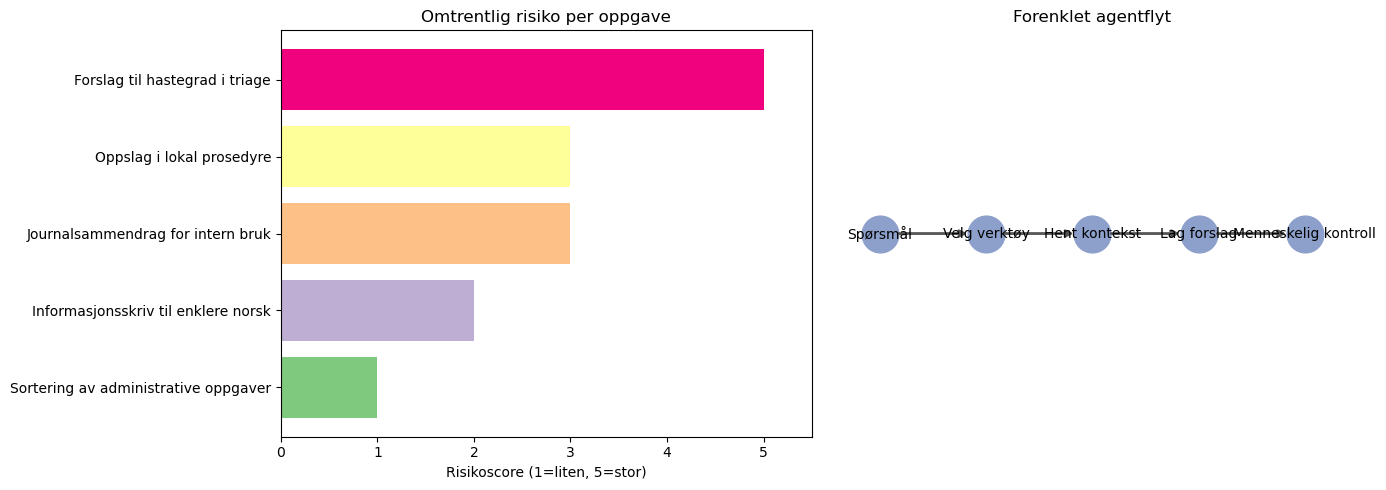

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualisering 1: risiko for ulike oppgaver
sortert = scenarioer.sort_values("Risikoscore")
axes[0].barh(sortert["Oppgave"], sortert["Risikoscore"], color=["#7fc97f", "#beaed4", "#fdc086", "#ffff99", "#f0027f"])
axes[0].set_title("Omtrentlig risiko per oppgave")
axes[0].set_xlabel("Risikoscore (1=liten, 5=stor)")
axes[0].set_xlim(0, 5.5)

# Visualisering 2: enkel agentflyt
steg = ["Spørsmål", "Velg verktøy", "Hent kontekst", "Lag forslag", "Menneskelig kontroll"]
x = list(range(len(steg)))
y = [1] * len(steg)
axes[1].scatter(x, y, s=700, color="#8da0cb")
for i in range(len(steg) - 1):
    axes[1].annotate(
        "",
        xy=(x[i + 1] - 0.15, y[i]),
        xytext=(x[i] + 0.15, y[i]),
        arrowprops=dict(arrowstyle="->", lw=2, color="#555555"),
    )
for xi, label in zip(x, steg):
    axes[1].text(xi, y[0], label, ha="center", va="center", fontsize=10)
axes[1].set_title("Forenklet agentflyt")
axes[1].set_xlim(-0.5, len(steg) - 0.5)
axes[1].set_ylim(0.8, 1.2)
axes[1].axis("off")

plt.tight_layout()
plt.show()
